# Constraint cosmological parameters and cosmic baryons

In [1]:
import sys
sys.path.append('../Python_scripts')
from tqdm import tqdm

## Import packages
from config import *
from support import *
from cosmo_support import *

# Show data

In [126]:
data=pd.read_csv('../Data/FRB.csv')
data

,FRB,z,DM_ext
0,FRB 20220204A,0.401200,509.43
1,FRB 20220207C,0.043300,132.98
2,FRB 20220208A,0.351000,296.65
3,FRB 20220307B,0.248100,313.43
4,FRB 20220310F,0.478000,366.71
...,...,...,...
75,FRB 20231226A,0.156900,134.90
76,FRB 20240114A,0.420000,437.70
77,FRB 20240201A,0.042729,286.50
78,FRB 20240210A,0.023686,202.73


In [127]:
print(len(data))
data = data[data['FRB'] != 'FRB 20190520B']
data = data[data['FRB'] != 'FRB 20220831A']
data = data[data['z'] >= 0.2]
# data = data[data['FRB'] == 'FRB 20230521B']
print(len(data))
data.head()

80
44


,FRB,z,DM_ext
0,FRB 20220204A,0.4012,509.43
2,FRB 20220208A,0.3510,296.65
3,FRB 20220307B,0.2481,313.43
4,FRB 20220310F,0.4780,366.71
5,FRB 20220330D,0.3714,378.75


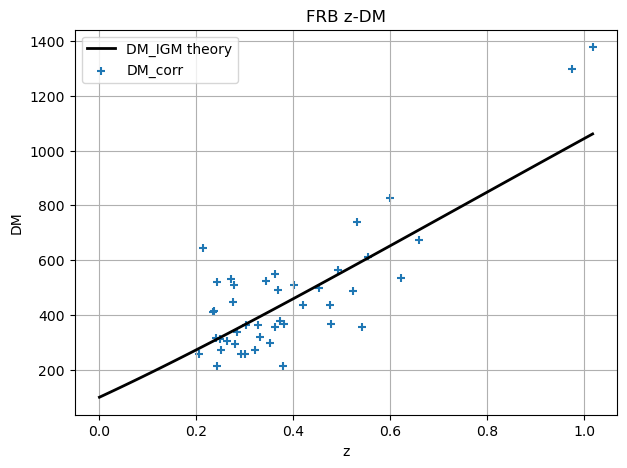

In [128]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(111)

z_range = np.linspace(0, np.max(data['z']), 100)

DM_theory = np.zeros_like(z_range)
for idx, redshift in enumerate(z_range):
    DM_theory[idx] = dispersion_measure(redshift, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = f_IGM)

ax1.plot(z_range, 100+DM_theory, lw=2, c='black', label='DM_IGM theory')
ax1.scatter(data['z'], data['DM_ext'], s=40, marker='+', label='DM_corr')  
ax1.set_xlabel('z')
ax1.set_ylabel('DM')
ax1.set_title('FRB z-DM')
ax1.grid(True)
ax1.legend()


plt.show()

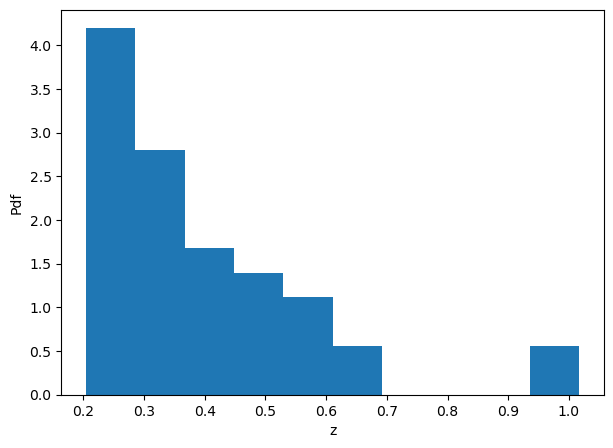

In [154]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(111)

ax1.hist(data['z'], density=True)
ax1.set_xlabel('z')
ax1.set_ylabel('Pdf')

plt.show()

In [160]:
np.ceil(np.max(data['z']))

2.0

In [177]:
bins_range = np.linspace(np.floor(np.min(data['z'])),\
                   np.ceil(np.max(data['z'])), 20)

In [178]:
bins_middles = (bins_range[1:]+bins_range[:-1])/2

In [179]:
bin_weights = n_val*bins_val[:-1]/np.sum(n_val*bins_val[:-1])

In [180]:
n_val, bins_val = np.histogram(data['z'], bins=bins_range)

In [202]:
z_mock = np.random.choice(bins_middles, size=len(data['z']), p=n_val/np.sum(n_val))

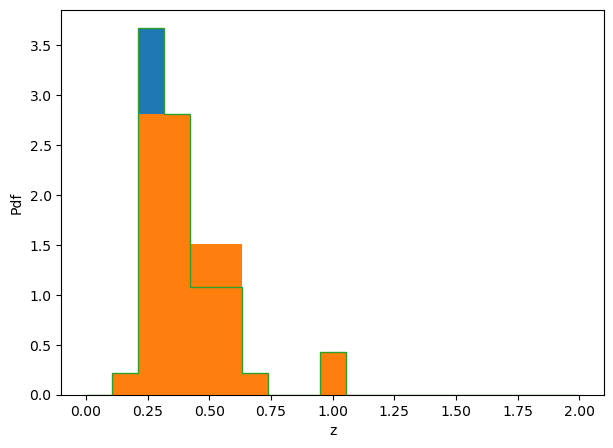

In [203]:
fig = plt.figure(figsize=(7,5))
ax1 = fig.add_subplot(111)

ax1.hist(data['z'], bins=bins_range, density=True)
ax1.hist(z_mock, bins=bins_range, density=True)

ax1.hist(bins_middles, bins=bins_range, weights=n_val, histtype='step', density=True)

ax1.set_xlabel('z')
ax1.set_ylabel('Pdf')

plt.show()

In [231]:
DM_mock = np.zeros_like(z_mock)

for idx, z in enumerate(z_mock):
    DM_mock[idx] = dispersion_measure(z, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = f_IGM)+100
    DM_mock[idx] += np.random.choice([-1, 1])*np.random.normal(0, 1e-1*DM_mock[idx])

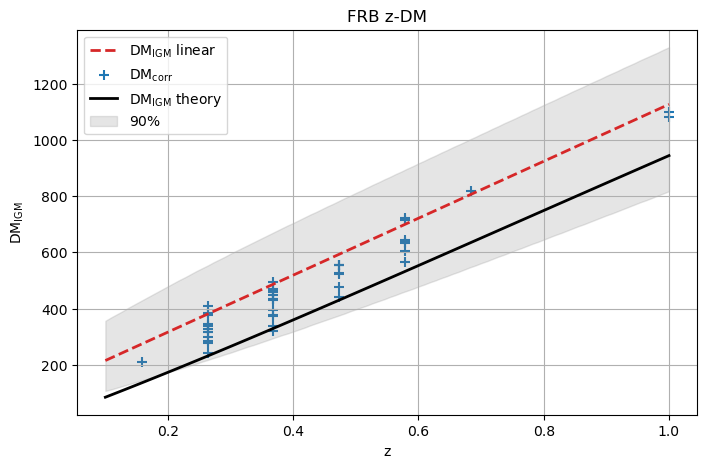

In [234]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(111)

z_range = np.linspace(0.1, np.max(z_mock), 100)
DM_theory = np.zeros_like(z_range)
y_high = np.zeros_like(z_range)
y_low = np.zeros_like(z_range)
DM_cosmic_range = np.linspace(0.01, 2000, 2000)


a = 1012.73
b = 113.70
DM_linear = a*z_range+b

for idx, z in enumerate(z_range):
    sigma=sigma_var(np.sqrt(f_variance_delta(F=5.5, z=z)))
    C0 = find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma(C_0=C0, sigma=sigma, alpha=3, beta=3)
    DM_theory[idx] = dispersion_measure(z, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = f_IGM)
    p=pdf_DM_cosmo(DM_cosmic_range/(100+DM_theory[idx]), C_0=C0, A=A, sigma=sigma)  
    
    ## Calculating the 5% and 95% limits, to plot the shaded area
    cdf = np.cumsum(normalise(p))
    y_high[idx] = DM_cosmic_range[np.argmin(np.abs(cdf-0.95))]
    y_low[idx] = DM_cosmic_range[np.argmin(np.abs(cdf-0.05))]    

ax1.plot(z_range, DM_linear, lw=2, ls='--', c='tab:red', label=r'DM$_{\rm IGM}$ linear')
ax1.scatter(z_mock, DM_mock, s=50, marker='+', label=r'DM$_{\rm corr}$')
ax1.plot(z_range, DM_theory, lw=2, c='black', label=r'DM$_{\rm IGM}$ theory')
ax1.fill_between(z_range, y_low, y_high, alpha=0.2, color='grey', label=r'$90\%$')


ax1.set_xlabel('z')
ax1.set_ylabel(r'DM$_{\rm IGM}$')
ax1.set_title('FRB z-DM')
ax1.grid(True)
ax1.legend()


plt.show()

# Preparation

search F range 

In [14]:
F_array=np.linspace(1.0, 18.0, 5)
sigma_host_array=np.linspace(0.2,1.4,10)
e_mu_array=np.linspace(50, 250, 10)

sigma variance relation

In [15]:
z_min=np.min(data['z'])
z_max=np.max(data['z'])
F_min=np.min(F_array)
F_max=np.max(F_array)
vars=[f_variance_delta(F_min,z_min),f_variance_delta(F_max,z_min),f_variance_delta(F_max,z_max),f_variance_delta(F_min,z_max)]
var_min=np.min(vars)
var_max=np.max(vars)
print([var_min,var_max])

[0.6054747196798983, 76.46371879346626]


In [16]:
s=2.554
C0=C0_sigma(s)
A=find_A_sigma(C_0=C0,sigma=s)
Af=find_A_sigma_fast(C_0=C0,sigma=s)

print([C0, A, Af])

[-2.0144531945899793, 0.5481994070884026, 0.5481992326782293]


../Python_scripts\cosmo_support.py:641: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  second_moment, _ = quad(second_moment_integrand, x_min, x_max,limit=limit)


80.54014114295425
0.00010023109830714638


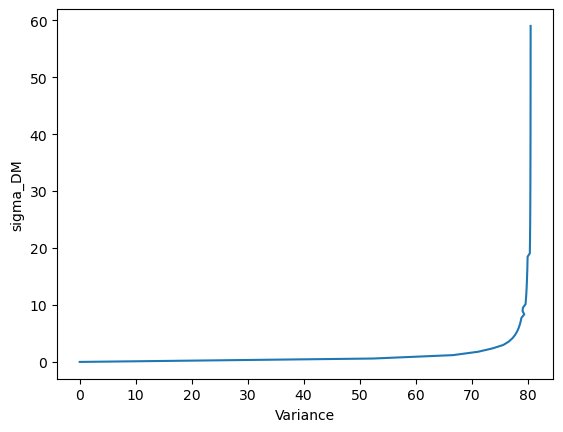

In [17]:
Sigmas=np.linspace(0.01, 59, 100)
Vars=np.zeros_like(Sigmas)

for i, sigma in enumerate(Sigmas):
    C0=C0_sigma(sigma)
    A = find_A_sigma(C_0=C0, sigma=sigma, alpha=3, beta=3)
    Vars[i]=calculate_var(C0=C0, A=A, sigma_DM=sigma)
    
plt.plot(Vars, Sigmas)
plt.ylabel('sigma_DM')
plt.xlabel('Variance')

print(np.max(Vars))
print(np.min(Vars))

In [18]:
sigma_var = interpolate.interp1d(np.sqrt(Vars), Sigmas, kind=1,bounds_error=False, 
    # fill_value='extrapolate'
    )

In [19]:
var=4
# 4.185538686543227
print(sigma_var(np.sqrt(var)))

0.17403681853078237


In [20]:
sigmas=[sigma_var(np.sqrt(var_min)),sigma_var(np.sqrt(var_max))]
sigma_min=np.min(sigmas)
sigma_max=np.max(sigmas)
print([sigma_min,sigma_max])

[0.07331618993684073, 3.4775131881213084]


In [21]:
sigma_rsl=200
# sigmas=np.linspace(sigma_min, sigma_max, sigma_rsl)
sigmas=np.linspace(0.1, 59.0, sigma_rsl)
print([np.min(sigmas),np.max(sigmas)])
C0s=np.zeros_like(sigmas)
As=np.zeros_like(sigmas)
for i, sigma in enumerate(sigmas):
    C0=C0_sigma(sigma)
    C0s[i]=C0
    As[i]=find_A_sigma(C_0=C0, sigma=sigma)

[0.1, 59.0]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


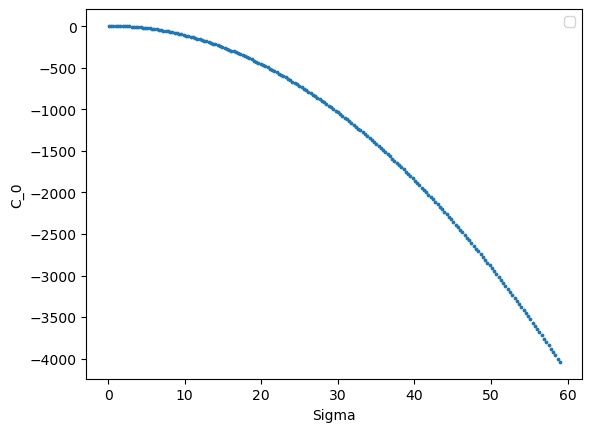

In [22]:
plt.scatter(sigmas, C0s,  s=3)

plt.ylabel('C_0')
plt.xlabel('Sigma')
plt.legend()

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


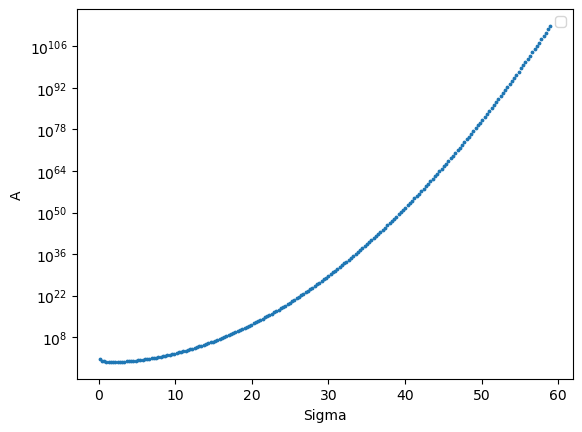

In [23]:
plt.scatter(sigmas, As,  s=3)

plt.ylabel('A')
plt.xlabel('Sigma')
plt.yscale('log')
plt.legend()

plt.show()

-------------------------------------------------------------

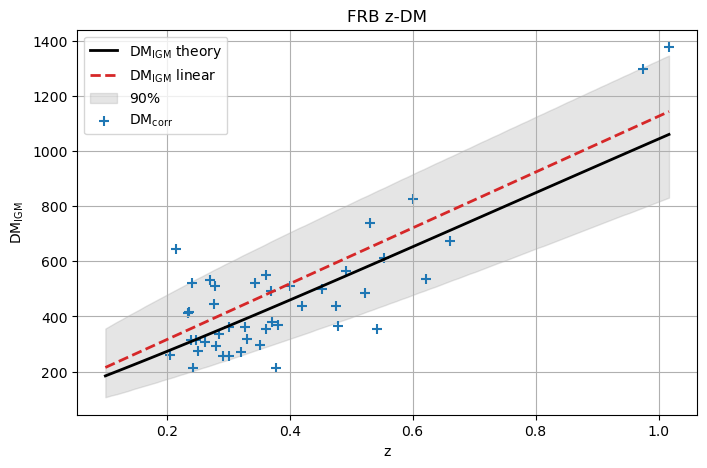

In [58]:
fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(111)

z_range = np.linspace(0.1, np.max(data['z']), 100)
y_high = np.zeros_like(z_range)
y_low = np.zeros_like(z_range)

a = 1012.73
b = 113.70
DM_linear = a*z_range+b

DM_theory = np.zeros_like(z_range)

## The range of DM_cosmic (the y-axis)
DM_cosmic_range = np.linspace(0.01, 2000, 2000)
    

for idx, z in enumerate(z_range):
    sigma=sigma_var(np.sqrt(f_variance_delta(F=5.5, z=z)))
    C0 = find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma(C_0=C0, sigma=sigma, alpha=3, beta=3)
    DM_theory[idx] = dispersion_measure(z, H0=HUBBLE, Om=OMEGA_MATTER, w=-1, alpha=0.11, f_IGM_0 = f_IGM)
    
    ## The range of DM_cosmic (the y-axis)
    # DM_cosmic_range = np.linspace(0.01, np.max(data['DM_ext'])/(DM_theory[idx]), 1000)
    p=pdf_DM_cosmo(DM_cosmic_range/(100+DM_theory[idx]), C_0=C0, A=A, sigma=sigma)
    
    ## Calculating the 5% and 95% limits, to plot the shaded area
    cdf = np.cumsum(normalise(p))
    y_high[idx] = DM_cosmic_range[np.argmin(np.abs(cdf-0.95))]
    y_low[idx] = DM_cosmic_range[np.argmin(np.abs(cdf-0.05))]
    

ax1.plot(z_range, 100+DM_theory, lw=2, c='black', label=r'DM$_{\rm IGM}$ theory')
ax1.plot(z_range, DM_linear, lw=2, ls='--', c='tab:red', label=r'DM$_{\rm IGM}$ linear')
ax1.fill_between(z_range, y_low, y_high, alpha=0.2, color='grey', label=r'$90\%$')


ax1.scatter(data['z'], data['DM_ext'], s=50, marker='+', label=r'DM$_{\rm corr}$')  

ax1.set_xlabel('z')
ax1.set_ylabel(r'DM$_{\rm IGM}$')
ax1.set_title('FRB z-DM')
ax1.grid(True)
ax1.legend()


plt.show()

Constrain $H_0 \Omega_0 f_{IGM}=const $

In [59]:
def DM_IGM_H0_O_b_f_IGM(z, H0_O_b_f_IGM, Om=OMEGA_MATTER, w=-1):
    
    def integrand(z, Om, w):
        return (1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))

    factor = 3*C_LIGHT*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    
    integral, _ = quad(integrand, 0, z, args=(Om, w))
    
    unit_transform = DM_2_PCCM3*KM_2_MPC
    
    DM = unit_transform*factor*integral
    
    return DM

In [60]:
def DM_IGM_H0_O_b_f_IGM_fast(z, H0_O_b_f_IGM, Om=OMEGA_MATTER, w=-1):
    
    def integrand(z, Om, w):
        return (1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))

    factor = 3*C_LIGHT*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    
    z_array = np.linspace(0, z, 1000)
    integral = np.trapz(integrand(z_array, Om, w), x=z_array)
    
    unit_transform = DM_2_PCCM3*KM_2_MPC
    
    DM = unit_transform*factor*integral
    
    return DM

In [61]:
z=1.00
print(DM_IGM_O_bh_70(z=z, O_bh_70=OMEGA_BARYONS*HUBBLE/70.0))
print(DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HUBBLE*OMEGA_BARYONS*f_IGM))

944.0949564541271
912.8582288974072


In [62]:
print(DM_IGM_H0_O_b_f_IGM_fast(z=z, H0_O_b_f_IGM=HUBBLE*OMEGA_BARYONS*f_IGM))

912.8581855784383


In [63]:
def calculate_dm_probability_num_HOf_v2(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0.01, DM_frb_max / DM_th-0.01, 5000)
    
    sigma=sigma_var(np.sqrt(f_variance_delta(F,z)))
    
    C_0=find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma(C_0=C_0, sigma=sigma, alpha=3, beta=3)
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    # print([f_variance_delta(F,z),sigma,C_0, A])
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [64]:
def calculate_dm_probability_num_HOf_fast(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM_fast(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0.01, DM_frb_max / DM_th-0.01, 5000)
    
    sigma=sigma_var(np.sqrt(f_variance_delta_fast(F,z)))
    
    C_0=find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma_fast(C_0=C_0, sigma=sigma, alpha=3, beta=3)
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    # print([f_variance_delta(F,z),sigma,C_0, A])
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [27]:
# def calculate_dm_probability_num_HOf(DM_frb_max, z, F, HOf, e_mu, sigma_host):
    
#     DM_host_array = np.linspace(0.01, DM_frb_max * (1+z)-0.01, 5000)

#     ## Host calculation
#     pdf_host = pdf_DM_host(DM_host_array, e_mu, sigma_host)
    
#     ## Cosmic calculation    
#     DM_th = DM_IGM_H0_O_b_f_IGM(z=z, H0_O_b_f_IGM=HOf, Om=OMEGA_MATTER, w=-1)
#     Deltas = (DM_frb_max-DM_host_array/(1+z))/DM_th
#     C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s,sigma_met="Mac")
#     A = find_A(C_0=C_0, F=F, z=z, alpha=3, beta=3,sigma_met="Mac")
#     pdf_cosmic = pdf_DM_cosmo(Deltas, C_0, A=A, sigma=f_sigma_DM(F,z), met="Mac")
    
#     ## Combine together    
#     prob = np.trapz(pdf_host*pdf_cosmic, x=DM_host_array)
    
#     ## Transform to probabilities
#     # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
#     return prob/DM_th

In [21]:
DM_frb_max=1174.1
z=1.354
F=10.0
HOf=3.0
e_mu=200
sigma_host=0.6

# print(calculate_dm_probability_num_HOf(DM_frb_max, z, F, HOf, e_mu, sigma_host))
print(calculate_dm_probability_num_HOf_v2(DM_frb_max, z, F, HOf, e_mu, sigma_host))
print(calculate_dm_probability_num_HOf_fast(DM_frb_max, z, F, HOf, e_mu, sigma_host))

0.0020514109767481147
0.0020514112805975733


In [22]:
import timeit

def timer_calculate_dm_probability():
    return calculate_dm_probability_num_HOf_v2(DM_frb_max, z, F, HOf, e_mu, sigma_host)

def timer_calculate_dm_prob():
    return calculate_dm_probability_num_HOf_fast(DM_frb_max, z, F, HOf, e_mu, sigma_host)

# time 
execution_time = timeit.timeit(timer_calculate_dm_probability, number=10)
print(f"calculate_dm_probability_mac time: {execution_time:.6f} seconds")
execution_time = timeit.timeit(timer_calculate_dm_prob, number=10)
print(f"calculate_dm_probability time: {execution_time:.6f} seconds")

calculate_dm_probability_mac time: 0.028010 seconds
calculate_dm_probability time: 0.013814 seconds


**NEED to fix some quads in the `cosmo_support`**

In [28]:
HOf_fiducial=70*OMEGA_BARYONS*0.9
print(HOf_fiducial)

3.0851100000000002


In [67]:
# F defined before
HOf_array=np.linspace(1.0, 5.0, 10)

F_4D, HOf_array_4D, sigma_host_4D, e_mu_4D = np.meshgrid(
    F_array, HOf_array, sigma_host_array, e_mu_array,
    indexing='ij'
    )

F_h, h_F = np.meshgrid(F_array, HOf_array)
F_sigma, sigma_F = np.meshgrid(F_array, sigma_host_array)
F_e_mu, e_mu_F = np.meshgrid(F_array, e_mu_array)

h_sigma, sigma_h = np.meshgrid(HOf_array, sigma_host_array)
h_e_mu, e_mu_h = np.meshgrid(HOf_array, e_mu_array)

sigma_e_mu, e_mu_sigma = np.meshgrid(sigma_host_array, e_mu_array)

print(fr'Shape of F_4D: {F_4D.shape}, HOf_array_4D: {HOf_array_4D.shape}, sigma_host_4D: {sigma_host_4D.shape}, e_mu_4D: {e_mu_4D.shape}')
print(fr'Shape of F_h: {F_h.shape}, h_F: {h_F.shape}, F_sigma: {F_sigma.shape}, sigma_F: {sigma_F.shape}, F_e_mu: {F_e_mu.shape}, e_mu_F: {e_mu_F.shape}')

Shape of F_4D: (5, 10, 10, 10), HOf_array_4D: (5, 10, 10, 10), sigma_host_4D: (5, 10, 10, 10), e_mu_4D: (5, 10, 10, 10)
Shape of F_h: (10, 5), h_F: (10, 5), F_sigma: (10, 5), sigma_F: (10, 5), F_e_mu: (10, 5), e_mu_F: (10, 5)


In [24]:
# posterior_4D = 1.0 + np.zeros_like(F_4D, dtype= np.float128)
log_posterior_4D = np.zeros_like(F_4D, dtype= np.float64)
# Calculate total iterations for progress bar
# total_iterations = len(data['FRB']) * len(F_array) * len(HOf_array) * len(sigma_host_array) * len(e_mu_array)
total_iterations = len(data['FRB'])

# Create flattened parameter combinations
param_combinations = [
    (F, HOf, sigma_host, e_mu)
    for F in F_array
    for HOf in HOf_array
    for sigma_host in sigma_host_array
    for e_mu in e_mu_array
]

# Initialize progress bar
pbar = tqdm(total=total_iterations, desc='Computing posteriors')
    
# Calculate and accumulate probabilities for each FRB
for _, row in data.iterrows():
    # Iterate through parameter combinations
    for idx, (F, HOf, sigma_host, e_mu) in enumerate(param_combinations):
        prob = calculate_dm_probability_num_HOf_fast(
            DM_frb_max=row['DM_ext'],
            z=row['z'],
            F=F,
            HOf=HOf,
            sigma_host=sigma_host,
            e_mu=e_mu
        )
        
        # Calculate indices for 4D array
        i = idx // (len(HOf_array) * len(sigma_host_array) * len(e_mu_array))
        j = (idx % (len(HOf_array) * len(sigma_host_array) * len(e_mu_array))) // (len(sigma_host_array) * len(e_mu_array))
        k = (idx % (len(sigma_host_array) * len(e_mu_array))) // len(e_mu_array)
        l = idx % len(e_mu_array)
    
        # Store result
        # print([i,j,k,l])
        # posterior_4D[i,j,k,l] = posterior_4D[i,j,k,l] * prob
        if prob > 0:
            log_posterior_4D[i,j,k,l] += np.log(prob)
        else:
            log_posterior_4D[i,j,k,l] = -np.inf
        
        # Update progress bar
        # pbar.update(1)
    
        # Optional: Add parameter values to progress bar description
        pbar.set_description(f"idx={_}, FRB={row['FRB']}, z={row['z']}, F={F:.2f}, HOf={HOf:.2f}, σ={sigma_host:.2f}, μ={e_mu:.2f}, prob={prob:.2f}")
    
    # # log_posterior = np.log(posterior_4D)
    log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
    if np.isfinite(log_sum):
        log_posterior_4D = log_posterior_4D - log_sum
    else:
        print(f"Warning: posterior sum is zero for FRB={row['FRB']}")
        break
            
    # posterior_4D_tot=np.sum(posterior_4D)
    # if posterior_4D_tot>0:
    #     posterior_4D=posterior_4D/posterior_4D_tot
    # else:
    #     print(f"posterior_4D_tot={posterior_4D_tot} at FRB={row['FRB']}")
    #     break
    
    pbar.update(1)
    pbar.set_description(f"FRB={row['FRB']}")

# Close progress bar
pbar.close()

FRB=FRB 20240114A: 100%|███████████████████████████████████████████████████████████████| 44/44 [19:22<00:00, 26.42s/it]


In [29]:
log_sum = np.logaddexp.reduce(log_posterior_4D.ravel())
if np.isfinite(log_sum):
    posterior_4D = np.exp(log_posterior_4D - log_sum)
else:
    print(f"Warning: posterior sum is zero")

np.save("./posterior/posterior_4D_mean_sqrt_fast.npy", posterior_4D)

In [65]:
posterior_4D = np.load("./posterior/posterior_4D_mean_sqrt.npy")
posterior_4D_fast = np.load("./posterior/posterior_4D_mean_sqrt_fast.npy")

C:\Users\klera\AppData\Local\Temp\ipykernel_23544\4215679271.py:22: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
C:\Users\klera\AppData\Local\Temp\ipykernel_23544\4215679271.py:45: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))


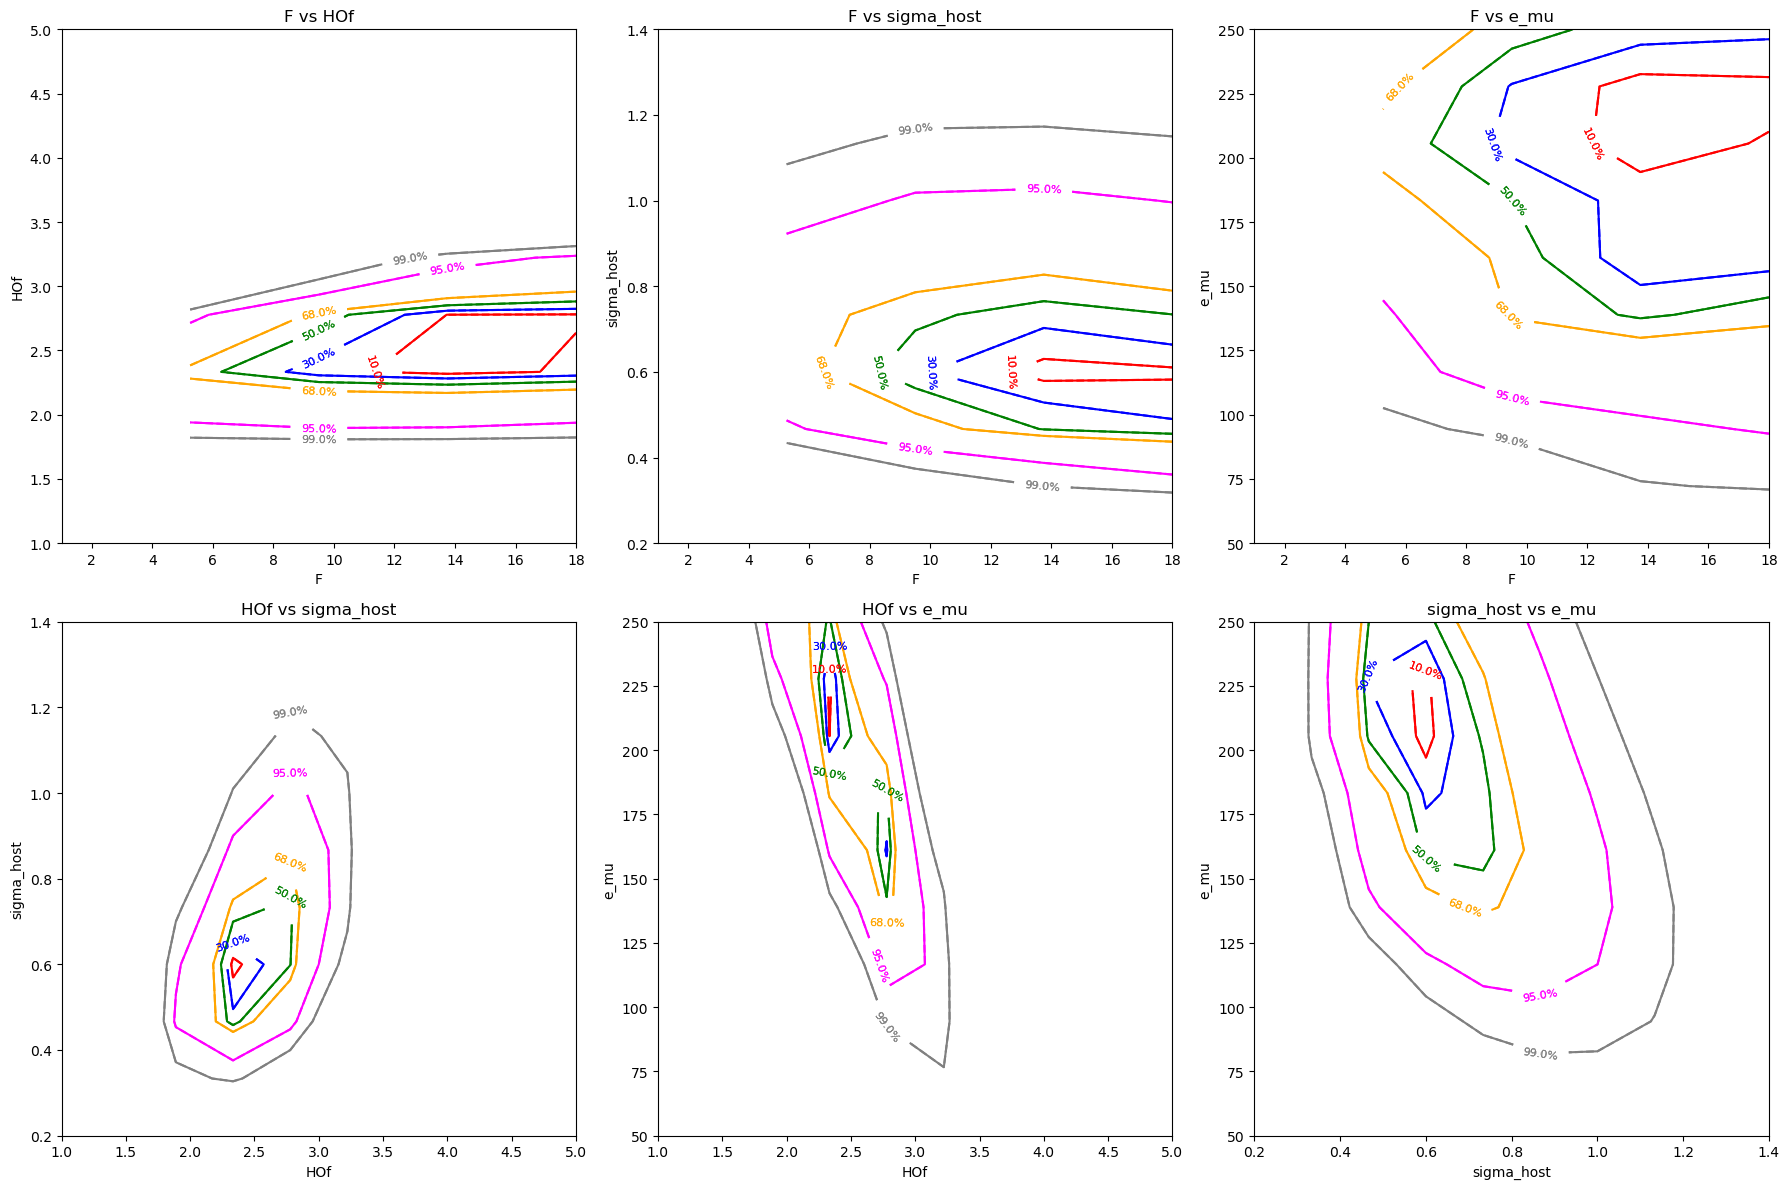

In [68]:
from scipy.stats import chi2

confidence_levels = [0.1,0.3,0.5,0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    ("F", "HOf", (2, 3), F_h, h_F),
    ("F", "sigma_host", (1, 3), F_sigma, sigma_F),
    ("F", "e_mu", (1, 2), F_e_mu, e_mu_F),
    ("HOf", "sigma_host", (0, 3), h_sigma, sigma_h),
    ("HOf", "e_mu", (0, 2), h_e_mu, e_mu_h),
    ("sigma_host", "e_mu", (0, 1), sigma_e_mu, e_mu_sigma)
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]

    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g', 'orange', 'magenta', 'grey'])
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%',
           contour_levels[3]: f'{confidence_levels[3]*100}%',
           contour_levels[4]: f'{confidence_levels[4]*100}%',
           contour_levels[5]: f'{confidence_levels[5]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=8)
    
    
for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D_fast, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]

    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g', 'orange', 'magenta', 'grey'], linestyles='--')
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%',
           contour_levels[3]: f'{confidence_levels[3]*100}%',
           contour_levels[4]: f'{confidence_levels[4]*100}%',
           contour_levels[5]: f'{confidence_levels[5]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=8)    

plt.tight_layout()
plt.show()

In [112]:
np.reverse(contour_levels)

AttributeError: module 'numpy' has no attribute 'reverse'

C:\Users\klera\AppData\Local\Temp\ipykernel_23544\2399843331.py:25: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))


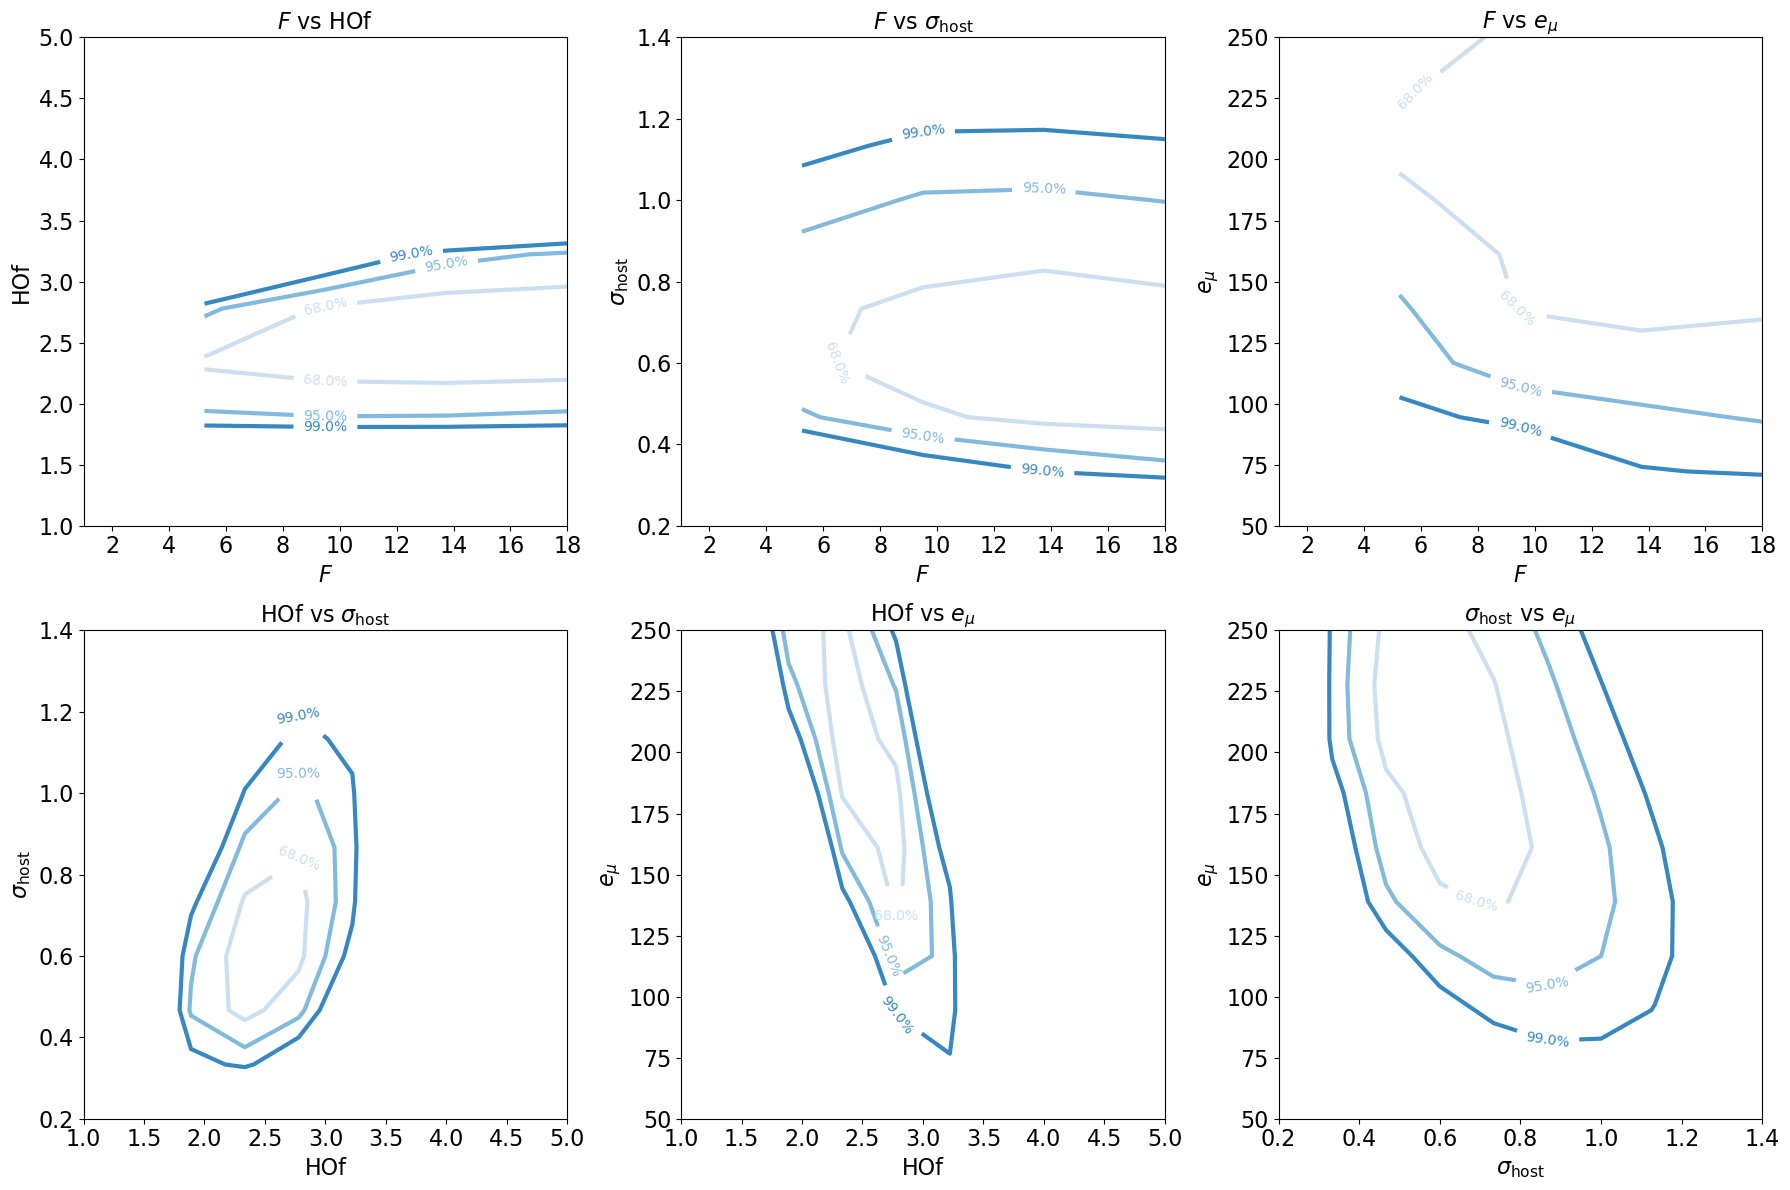

In [125]:
from scipy.stats import chi2

confidence_levels = [0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    (r"$F$", "HOf", (2, 3), F_h, h_F),
    (r"$F$", r"$\sigma_{\rm host}$", (1, 3), F_sigma, sigma_F),
    (r"$F$", r"$e_{\mu}$", (1, 2), F_e_mu, e_mu_F),
    ("HOf", r"$\sigma_{\rm host}$", (0, 3), h_sigma, sigma_h),
    ("HOf", r"$e_{\mu}$", (0, 2), h_e_mu, e_mu_h),
    (r"$\sigma_{\rm host}$", r"$e_{\mu}$", (0, 1), sigma_e_mu, e_mu_sigma)
]

blues = cm.get_cmap("Blues", 10)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
  
    
for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D_fast, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]

    # cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g'], linestyles='--')
    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=[blues(2), blues(4), blues(6)], extend='max', linewidths=3)
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=10)
    for label in ([ax.title, ax.xaxis.label, ax.yaxis.label] + ax.get_xticklabels() + ax.get_yticklabels()):
        # label.set_fontname('Arial')
        label.set_fontsize(16)

plt.tight_layout()
plt.show()

Constrain $H_0 \Omega_0 f_{IGM}=H_0 \Omega_0 f_{IGM,0}(1+a
\cdot z)$

In [24]:
def DM_IGM_H0_O_b_f_IGM_linear(z, H0_O_b_f_IGM, a, Om=OMEGA_MATTER, w=-1):
    
    def integrand(z, Om, w):
        return (1+a*z)*(1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))

    factor = 3*C_LIGHT*KM_2_MPC*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    
    
    integral, _ = quad(integrand, 0, z, args=(Om, w))
    
    unit_transform = DM_2_PCCM3
    
    DM = unit_transform*factor*integral
    
    return DM

In [25]:
# def calculate_dm_probability_num_HOf_linear(DM_frb_max, z, F, HOf, a ,e_mu, sigma_host):
    
#     DM_host_array = np.linspace(0.01, DM_frb_max * (1+z)-0.01, 5000)

#     ## Host calculation
#     pdf_host = pdf_DM_host(DM_host_array, e_mu, sigma_host)
    
#     ## Cosmic calculation    
#     DM_th = DM_IGM_H0_O_b_f_IGM_linear(z=z, H0_O_b_f_IGM=HOf, a=a, Om=OMEGA_MATTER, w=-1)
#     Deltas = (DM_frb_max-DM_host_array/(1+z))/DM_th
#     C_0=find_C0(F=F, z=z, sigmas=sigmas, C0s=C0s,sigma_met="Mac")
#     A = find_A(C_0=C_0, F=F, z=z, alpha=3, beta=3,sigma_met="Mac")
#     pdf_cosmic = pdf_DM_cosmo(Deltas, C_0, A=A, sigma=f_sigma_DM(F,z, met="Mac"))
    
#     ## Combine together    
#     prob = np.trapz(pdf_host*pdf_cosmic, x=DM_host_array)
    
#     ## Transform to probabilities
#     # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
#     return prob/DM_th

In [26]:
def calculate_dm_probability_num_HOf_linear_v2(DM_frb_max, z, F, HOf, a ,e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM_linear(z=z, H0_O_b_f_IGM=HOf, a=a, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0.01, DM_frb_max / DM_th-0.01, 5000)
    
    sigma=sigma_var(f_variance_delta(F,z))
    
    C_0=find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma(C_0=C_0, sigma=sigma, alpha=3, beta=3)
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [27]:
F_array=np.linspace(1, 5, 10)
sigma_host_array=np.linspace(0.2,1.6,10)
e_mu_array=np.linspace(50,250, 10)
HOf_array=np.linspace(1.0,5.0, 10)
a_array=np.linspace(0, 0.2, 10)

F_5D, HOf_array_5D, a_array_5D, sigma_host_5D, e_mu_5D = np.meshgrid(
    F_array, HOf_array, a_array, sigma_host_array, e_mu_array,
    indexing='ij'
    )

F_h, h_F = np.meshgrid(F_array, HOf_array)
F_a, a_F = np.meshgrid(F_array, a_array)
F_sigma, sigma_F = np.meshgrid(F_array, sigma_host_array)
F_e_mu, e_mu_F = np.meshgrid(F_array, e_mu_array)

h_a, a_h = np.meshgrid(HOf_array, a_array)
h_sigma, sigma_h = np.meshgrid(HOf_array, sigma_host_array)
h_e_mu, e_mu_h = np.meshgrid(HOf_array, e_mu_array)

a_sigma, sigma_a = np.meshgrid(a_array, sigma_host_array)
a_e_mu, e_mu_a = np.meshgrid(a_array, e_mu_array)

sigma_e_mu, e_mu_sigma = np.meshgrid(sigma_host_array, e_mu_array)

print(fr'Shape of F_5D: {F_5D.shape}, HOf_array_5D: {HOf_array_5D.shape}, a_array_5D: {a_array_5D.shape}, sigma_host_5D: {sigma_host_5D.shape}, e_mu_5D: {e_mu_5D.shape}')
print(fr'Shape of F_h: {F_h.shape}, h_F: {h_F.shape}, F_a: {F_a.shape}, a_F: {a_F.shape}, F_sigma: {F_sigma.shape}, sigma_F: {sigma_F.shape}, F_e_mu: {F_e_mu.shape}, e_mu_F: {e_mu_F.shape}')

Shape of F_5D: (10, 10, 10, 10, 10), HOf_array_5D: (10, 10, 10, 10, 10), a_array_5D: (10, 10, 10, 10, 10), sigma_host_5D: (10, 10, 10, 10, 10), e_mu_5D: (10, 10, 10, 10, 10)
Shape of F_h: (10, 10), h_F: (10, 10), F_a: (10, 10), a_F: (10, 10), F_sigma: (10, 10), sigma_F: (10, 10), F_e_mu: (10, 10), e_mu_F: (10, 10)


In [28]:
# posterior_5D = 1.0 + np.zeros_like(F_5D, dtype= np.float128)
log_posterior_5D = np.zeros_like(F_5D, dtype= np.float64)
# Calculate total iterations for progress bar
# total_iterations = len(data['FRB']) * len(F_array) * len(HOf_array) * len(a_array) * len(sigma_host_array) * len(e_mu_array)
total_iterations = len(data['FRB'])

# Create flattened parameter combinations
param_combinations = [
    (F, HOf, a, sigma_host, e_mu)
    for F in F_array
    for HOf in HOf_array
    for a in a_array
    for sigma_host in sigma_host_array
    for e_mu in e_mu_array
]

# Initialize progress bar
pbar = tqdm(total=total_iterations, desc='Computing posteriors')
    
# Calculate and accumulate probabilities for each FRB
for _, row in data.iterrows():
    # Iterate through parameter combinations
    for idx, (F, HOf, a, sigma_host, e_mu) in enumerate(param_combinations):
        prob = calculate_dm_probability_num_HOf_linear_v2(
            DM_frb_max=row['DM_ext'],
            z=row['z'],
            F=F,
            HOf=HOf,
            a=a,
            sigma_host=sigma_host,
            e_mu=e_mu
        )
        
        # Calculate indices for 5D array
        i = idx // (len(HOf_array) * len(a_array) * len(sigma_host_array) * len(e_mu_array))
        j = (idx % (len(HOf_array) * len(a_array) * len(sigma_host_array) * len(e_mu_array))) // (len(a_array) * len(sigma_host_array) * len(e_mu_array))
        k = (idx % (len(a_array) * len(sigma_host_array) * len(e_mu_array))) // (len(sigma_host_array) * len(e_mu_array))
        l = (idx % (len(sigma_host_array) * len(e_mu_array))) // len(e_mu_array)
        m = idx % len(e_mu_array)
    
        # Store result
        # posterior_5D[i,j,k,l,m] = posterior_5D[i,j,k,l,m] * prob
        if prob > 0:
            log_posterior_5D[i,j,k,l,m] += np.log(prob)
        else:
            log_posterior_5D[i,j,k,l,m] = -np.inf
        
        # # Update progress bar
        # pbar.update(1)
    
        # # Optional: Add parameter values to progress bar description
        # pbar.set_description(f"idx={_}, FRB={row['FRB']}, F={F:.2f}, HOf={HOf:.2f}, a={a:.2f}, σ={sigma_host:.2f}, μ={e_mu:.2f}")
    
    log_sum = np.logaddexp.reduce(log_posterior_5D.ravel())
    if np.isfinite(log_sum):
        posterior_5D = np.exp(log_posterior_5D - log_sum)
    else:
        print(f"Warning: posterior sum is zero for FRB={row['FRB']}")
        break
    
    # posterior_5D_tot=np.sum(posterior_5D)
    # if posterior_5D_tot>0:
    #     posterior_5D=posterior_5D/posterior_5D_tot
    # else:
    #     print(f"posterior_5D_tot={posterior_5D_tot} at FRB={row['FRB']}")
    #     break
    
    pbar.update(1)
    pbar.set_description(f"FRB={row['FRB']}")

# Close progress bar
pbar.close()

FRB=FRB 20231025B: 100%|██████████| 56/56 [2:37:21<00:00, 168.59s/it]  


In [29]:
log_sum = np.logaddexp.reduce(log_posterior_5D.ravel())
if np.isfinite(log_sum):
    posterior_5D = np.exp(log_posterior_5D - log_sum)
else:
    print(f"Warning: posterior sum is zero")

np.save("./posterior/posterior_5D_mean.npy", posterior_5D)

In [30]:
posterior_5D = np.load("./posterior/posterior_5D_mean.npy")
print(np.sum(posterior_5D))

1.00000000000312


In [31]:
print(posterior_5D[5,:,3,1,6])

[6.28995393e-068 4.01433273e-045 1.02379344e-025 4.50949366e-013
 3.62158102e-013 6.09148709e-036 3.34624545e-097 8.96057117e-222
 0.00000000e+000 0.00000000e+000]


/var/folders/9w/bbgy16c17_g3tqprqy1t6jcr0000gn/T/ipykernel_32504/1337276825.py:26: RuntimeWarning: divide by zero encountered in log
  delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))


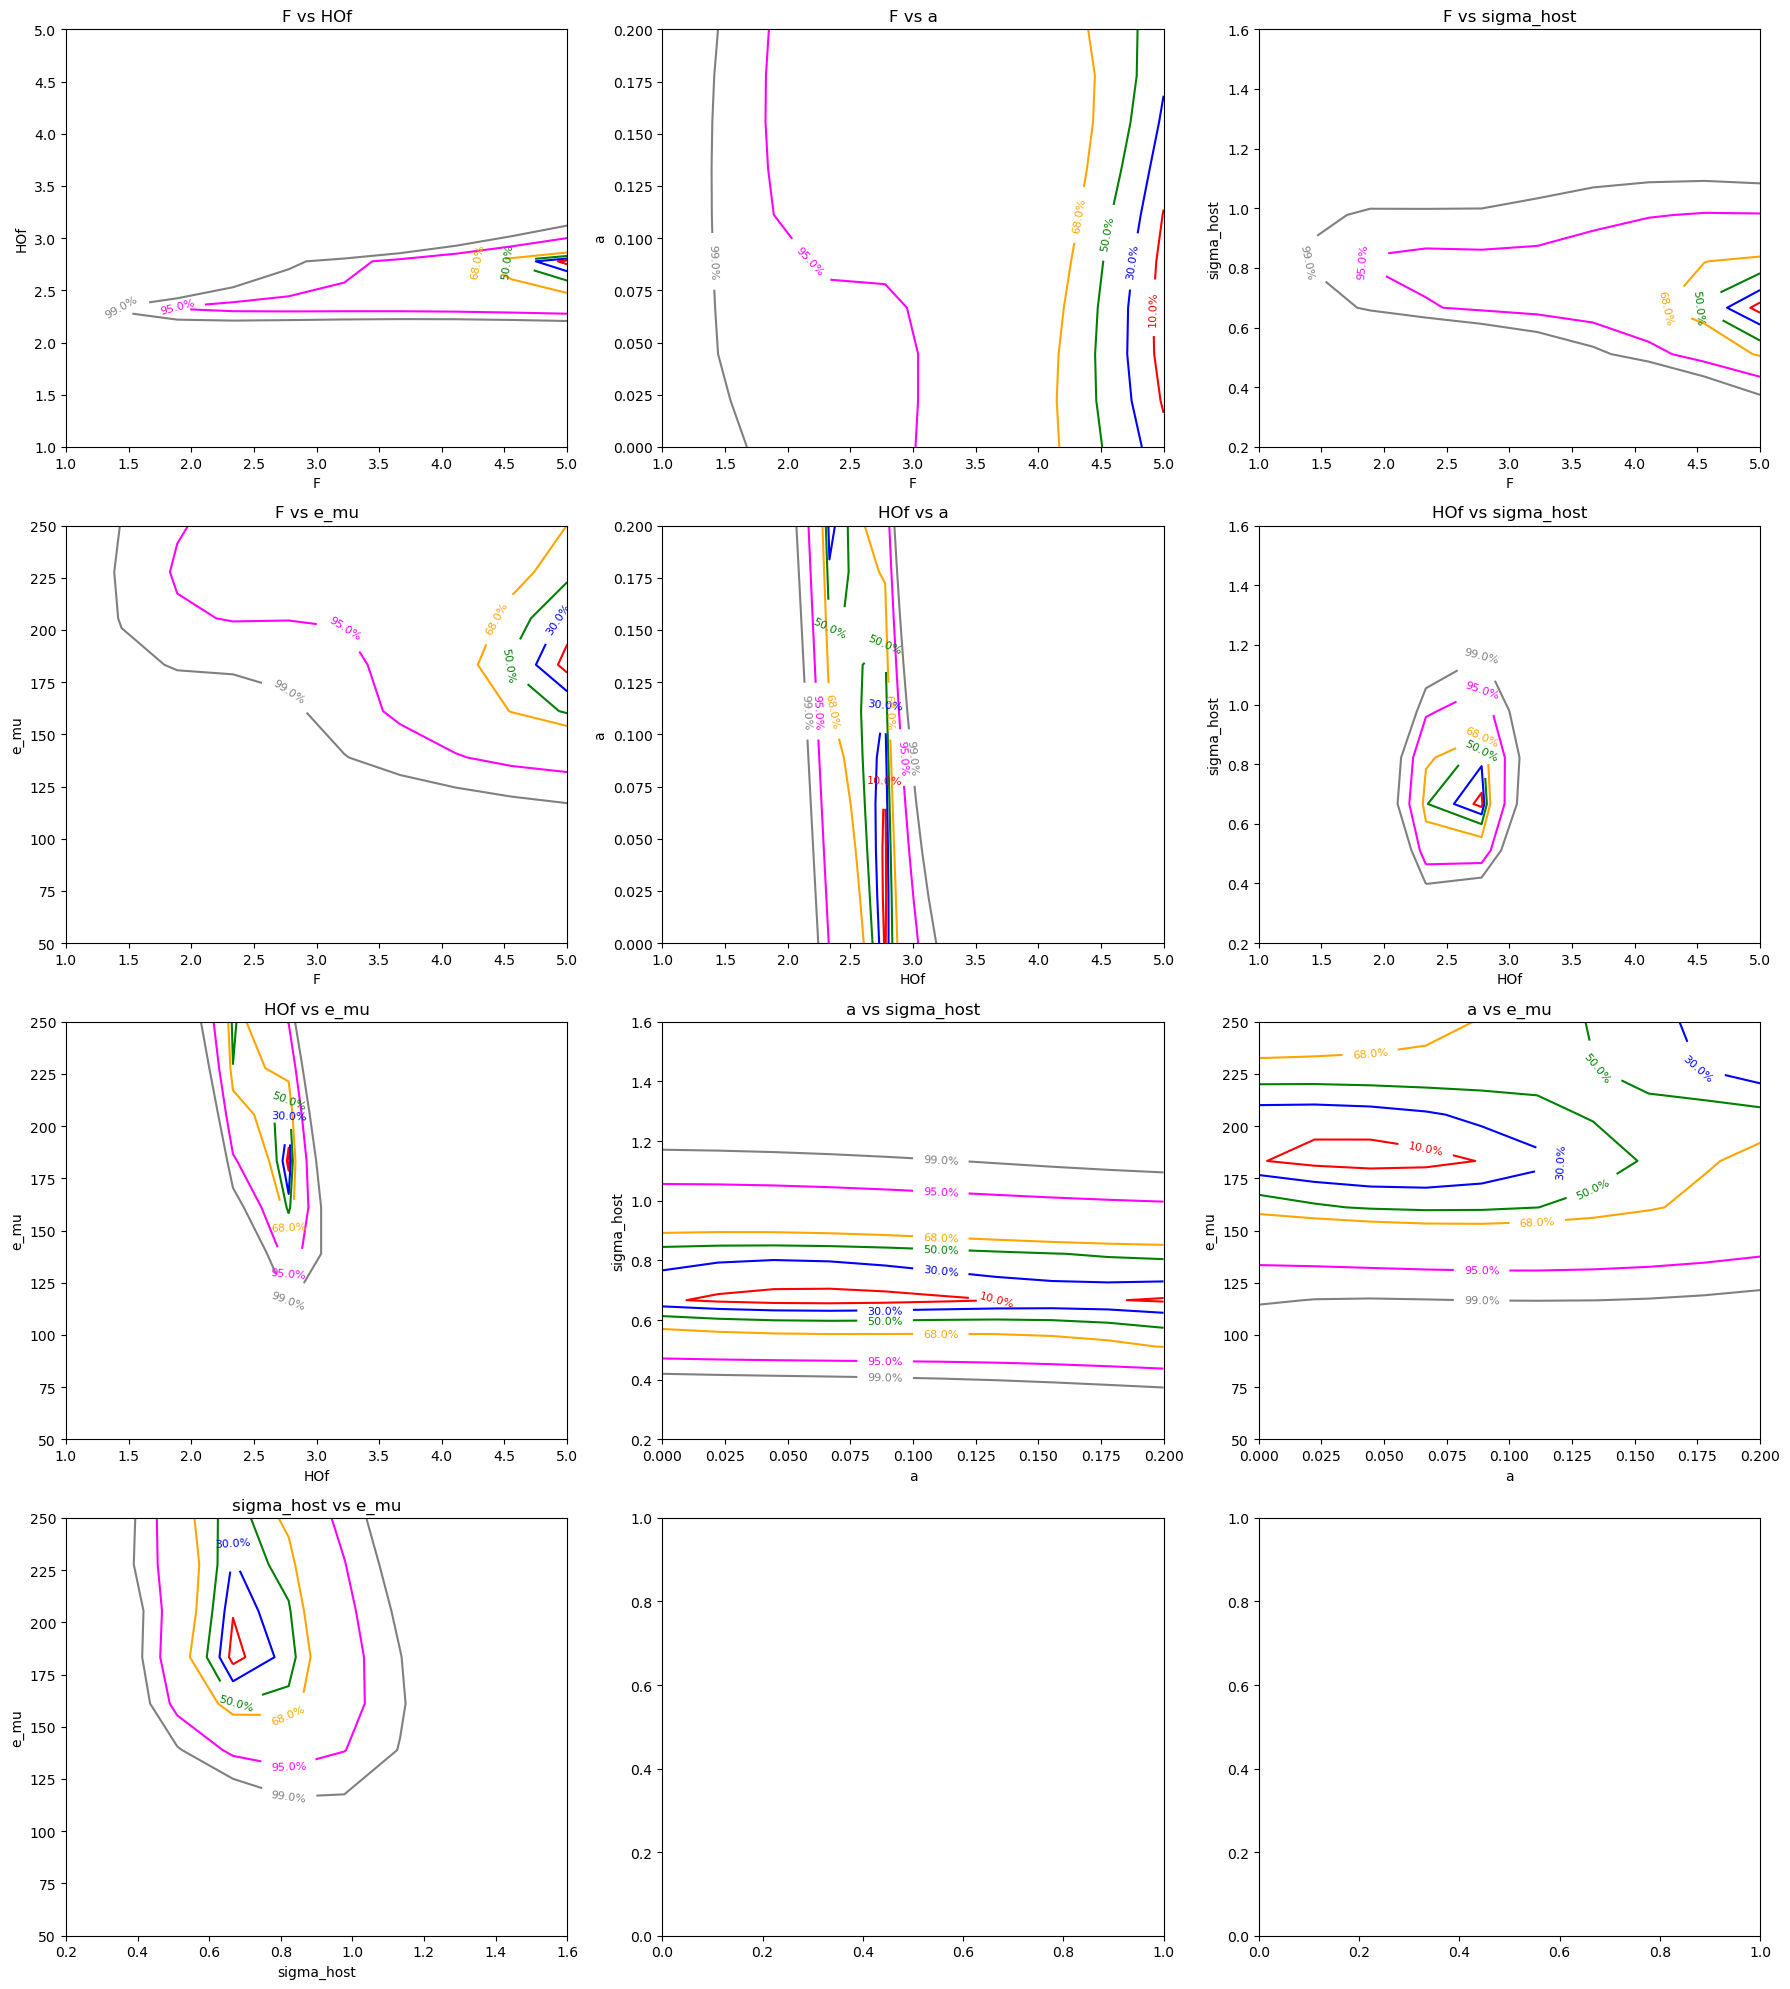

In [32]:
from scipy.stats import chi2

confidence_levels = [0.1,0.3,0.5,0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    ("F", "HOf", (2, 3, 4), F_h, h_F),
    ("F", "a", (1, 3, 4), F_a, a_F),
    ("F", "sigma_host", (1, 2, 4), F_sigma, sigma_F),
    ("F", "e_mu", (1, 2, 3), F_e_mu, e_mu_F),
    ("HOf", "a", (0, 3, 4), h_a, a_h),
    ("HOf", "sigma_host", (0, 2, 4), h_sigma, sigma_h),
    ("HOf", "e_mu", (0, 2, 3), h_e_mu, e_mu_h),
    ("a", "sigma_host", (0, 1, 4), a_sigma, sigma_a),
    ("a", "e_mu", (0, 1, 3), a_e_mu, e_mu_a),
    ("sigma_host", "e_mu", (0, 1, 2), sigma_e_mu, e_mu_sigma)
]

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_5D, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]

    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g', 'orange', 'magenta', 'grey'])
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100}%', 
           contour_levels[1]: f'{confidence_levels[1]*100}%',
           contour_levels[2]: f'{confidence_levels[2]*100}%',
           contour_levels[3]: f'{confidence_levels[3]*100}%',
           contour_levels[4]: f'{confidence_levels[4]*100}%',
           contour_levels[5]: f'{confidence_levels[5]*100}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=8)

plt.tight_layout()
plt.show()